# Pass 2: testing the LightGBM ranker as it's built

Scratch notebook for trying out Pass 2 pieces as they land, starting with the interface refactor (`rank_fn`/`optimiser_fn`) and the LightGBM training panel builder. This notebook will grow as `rank_by_lgbm` (the actual fit/predict step) and later Pass 2 items get built — it's not part of the pipeline itself, just a place to poke at things.

Kernel: select **portfolio-constructor** (the project's `.venv`).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.data import ingest, features
from src.models import ranker, lgbm_ranker
from src.portfolio import backtest

## 1. Pull data (cached after the first run)

In [2]:
prices_long = ingest.load_or_fetch_prices(
    config.TICKER_UNIVERSE + [config.BENCHMARK_TICKER], config.DATA_START_DATE, config.DATA_END_DATE
)
dividends = ingest.load_or_fetch_dividends(config.TICKER_UNIVERSE, config.DATA_START_DATE, config.DATA_END_DATE)
prices = ingest.to_wide_adj_close(prices_long)
universe_prices = prices[config.TICKER_UNIVERSE]
print("prices (wide):", prices.shape)

prices (wide): (2906, 40)


## 2. The refactored `rank_fn` / `optimiser_fn` interface

`backtest.py`'s pluggable ranking rule used to be `score_fn(momentum, low_volatility, dividend_yield)` — three already-computed factor snapshots in, scores out. That doesn't work for a model that needs to build its own training panel across many dates (like LightGBM), so it broadened to `rank_fn(universe_prices, dividends, as_of_date)` — raw data in, scores out. `ranker.rank_by_composite_score` and `ranker.rank_by_momentum_only` are thin adapters that compute the three factors internally and delegate to the original `score_stocks`/`score_by_momentum_only`, so nothing about the composite/momentum-only strategies actually changed — just how they plug in.

In [3]:
as_of_date = pd.Timestamp("2023-01-03")

composite_scores = ranker.rank_by_composite_score(universe_prices, dividends, as_of_date)
momentum_scores = ranker.rank_by_momentum_only(universe_prices, dividends, as_of_date)

print("Top 5, composite score:")
print(composite_scores.sort_values(ascending=False).head())
print("\nTop 5, momentum-only:")
print(momentum_scores.sort_values(ascending=False).head())

Top 5, composite score:
ticker
T      1.235576
XOM    0.960818
VZ     0.938758
MRK    0.884379
COP    0.845785
dtype: float64

Top 5, momentum-only:
ticker
XOM     2.702532
COP     2.475886
CVX     1.962992
MRK     1.618386
ABBV    0.920853
dtype: float64


In [4]:
# Confirm run_backtest still works through the new interface and reproduces
# the same numbers already seen in notebook 1 (default rank_fn/optimiser_fn
# match the old score_fn defaults exactly).
daily_returns, _ = backtest.run_backtest(prices, dividends)
print("composite strategy_net final growth:", (1 + daily_returns["strategy_net"]).cumprod().iloc[-1])

composite strategy_net final growth: 2.293325185870729


## 3. `features.training_window`'s `extra_months`

The LightGBM panel needs a *wider* window than a single as-of-date query: its earliest training snapshot needs its own 12-month momentum lookback before the window even starts. `extra_months` widens the window's start without moving its end.

In [5]:
standard_window = features.training_window(universe_prices, as_of_date)
widened_window = features.training_window(universe_prices, as_of_date, extra_months=config.MOMENTUM_LOOKBACK_MONTHS)

print("standard window:", standard_window.index.min().date(), "to", standard_window.index.max().date())
print("widened window: ", widened_window.index.min().date(), "to", widened_window.index.max().date())
print("same end date:", standard_window.index.max() == widened_window.index.max())

standard window: 2020-01-03 to 2022-12-30
widened window:  2019-01-03 to 2022-12-30
same end date: True


## 4. The LightGBM training panel

One row per ticker per historical monthly snapshot: the three factors as of that snapshot date, plus the *realized* forward 1-month return (the label). This is what `rank_by_lgbm` will fit a model on — built here directly to inspect it before that step exists.

In [6]:
panel = lgbm_ranker._build_training_panel(universe_prices, dividends, as_of_date)

print("panel shape:", panel.shape)
print("snapshot dates:", panel["snapshot_date"].nunique(), "-", panel["snapshot_date"].min().date(), "to", panel["snapshot_date"].max().date())
print("tickers:", panel["ticker"].nunique())
panel.head()

panel shape: (1365, 6)
snapshot dates: 35 - 2020-01-31 to 2022-11-30
tickers: 39


,momentum,low_volatility,dividend_yield,forward_return,ticker,snapshot_date
0,0.790808,0.014480,0.009744,-0.114701,AAPL,2020-01-31
1,0.532431,0.011752,0.011572,-0.045688,MSFT,2020-01-31
2,0.189628,0.014277,0.000000,-0.065279,GOOGL,2020-01-31
3,0.075119,0.013000,0.000000,-0.062214,AMZN,2020-01-31
4,0.231328,0.015843,0.000000,-0.046754,META,2020-01-31


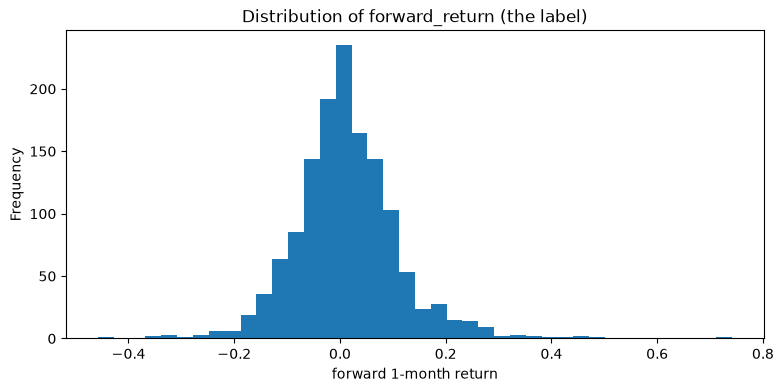

count    1365.000000
mean        0.012207
std         0.099147
min        -0.457890
25%        -0.043610
50%         0.007340
75%         0.064469
max         0.741452
Name: forward_return, dtype: float64

In [7]:
panel["forward_return"].plot.hist(bins=40, figsize=(9, 4), title="Distribution of forward_return (the label)")
plt.xlabel("forward 1-month return")
plt.show()
panel["forward_return"].describe()

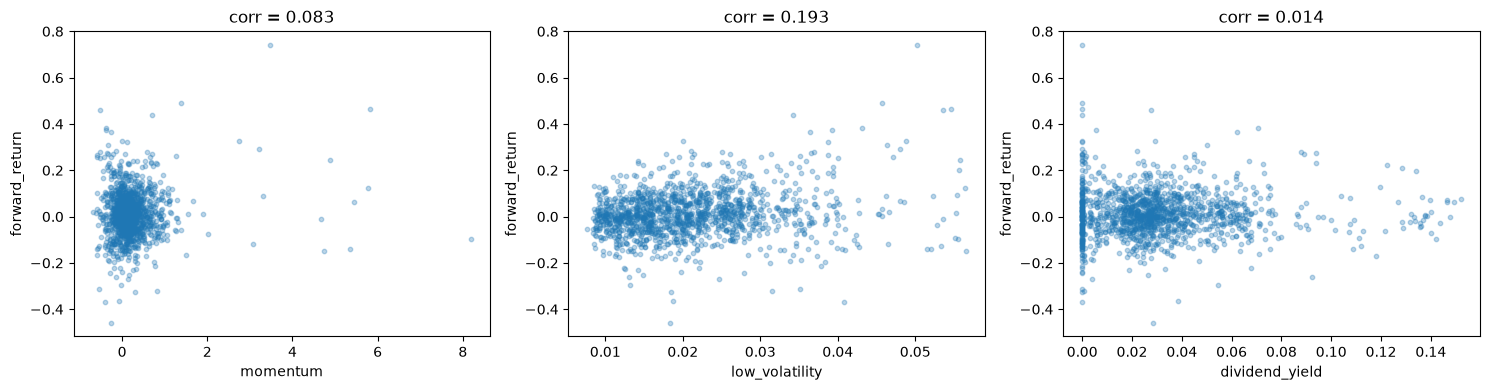

In [8]:
# Is there any visible relationship between a feature and what actually happened
# next? Weak/noisy is expected and normal for a single factor at the individual
# stock-month level — this is just an eyeball check, not a rigorous signal test.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feature_name in zip(axes, ["momentum", "low_volatility", "dividend_yield"]):
    ax.scatter(panel[feature_name], panel["forward_return"], alpha=0.3, s=10)
    ax.set_xlabel(feature_name)
    ax.set_ylabel("forward_return")
    correlation = panel[feature_name].corr(panel["forward_return"])
    ax.set_title(f"corr = {correlation:.3f}")
plt.tight_layout()
plt.show()

## 5. Full walk-forward comparison: LightGBM vs composite vs momentum-only vs equal-weight vs SPY

`rank_by_lgbm` now exists — run it through the exact same walk-forward backtest as everything else (rolling training window, transaction costs, both benchmarks) and see how it actually performs, not just what it predicts at one snapshot.

In [9]:
from src.risk import metrics

composite_returns, composite_log = backtest.run_backtest(prices, dividends)
momentum_returns, _ = backtest.run_backtest(prices, dividends, rank_fn=ranker.rank_by_momentum_only)
lgbm_returns, lgbm_log = backtest.run_backtest(prices, dividends, rank_fn=lgbm_ranker.rank_by_lgbm)

print("rebalances:", len(lgbm_log))
print("LightGBM strategy_net final growth:", (1 + lgbm_returns["strategy_net"]).cumprod().iloc[-1])

rebalances: 90
LightGBM strategy_net final growth: 5.169676393638587


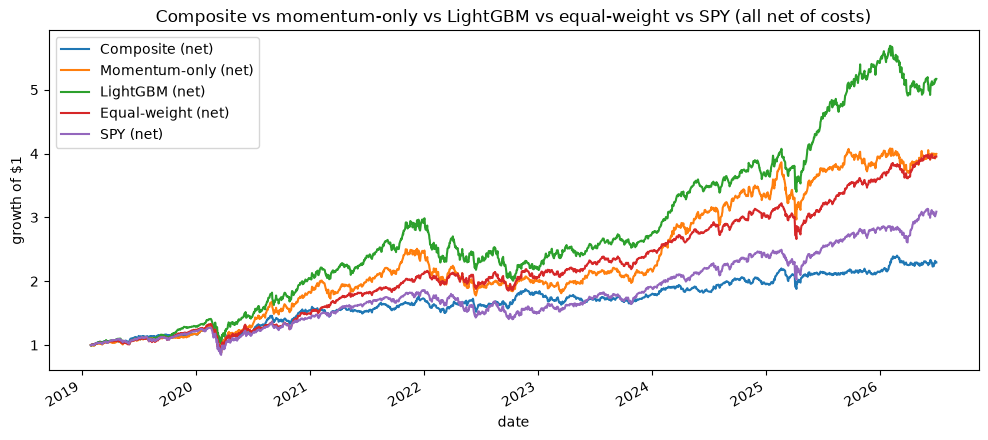

In [10]:
five_way = pd.DataFrame(
    {
        "Composite (net)": composite_returns["strategy_net"],
        "Momentum-only (net)": momentum_returns["strategy_net"],
        "LightGBM (net)": lgbm_returns["strategy_net"],
        "Equal-weight (net)": composite_returns["equal_weight_net"],
        "SPY (net)": composite_returns["sp500_net"],
    }
)
(1 + five_way).cumprod().plot(
    figsize=(12, 5), title="Composite vs momentum-only vs LightGBM vs equal-weight vs SPY (all net of costs)"
)
plt.ylabel("growth of $1")
plt.show()

In [11]:
five_way_comparison = pd.DataFrame(
    {
        "composite": metrics.compute_all(composite_returns["strategy_net"]),
        "momentum_only": metrics.compute_all(momentum_returns["strategy_net"]),
        "lightgbm": metrics.compute_all(lgbm_returns["strategy_net"]),
        "equal_weight": metrics.compute_all(composite_returns["equal_weight_net"]),
        "SPY": metrics.compute_all(composite_returns["sp500_net"]),
    }
)
five_way_comparison

,composite,momentum_only,lightgbm,equal_weight,SPY
sharpe_ratio,0.611852,0.885559,1.069710,1.016483,0.778942
sortino_ratio,0.753571,1.109423,1.362976,1.192044,0.953946
max_drawdown,-0.327758,-0.327841,-0.327408,-0.341291,-0.337173
historical_var_95,-0.013737,-0.020228,-0.020330,-0.014781,-0.017436
monte_carlo_var_95,-0.018090,-0.021872,-0.021150,-0.018095,-0.019845
expected_shortfall_95,-0.024476,-0.031541,-0.031225,-0.026607,-0.029236
var_breaches_95,94.000000,94.000000,94.000000,94.000000,94.000000
historical_var_99,-0.026300,-0.035117,-0.037390,-0.030315,-0.033974
monte_carlo_var_99,-0.025863,-0.031363,-0.030395,-0.025993,-0.028425
expected_shortfall_99,-0.048954,-0.055585,-0.052183,-0.051017,-0.051986


In [12]:
print("Holdings at the most recent rebalance:")
print("  composite (z-score):", composite_log["selected_tickers"].iloc[-1])
print("  LightGBM:            ", lgbm_log["selected_tickers"].iloc[-1])

Holdings at the most recent rebalance:
  composite (z-score): ['PFE', 'VZ', 'CVX', 'T', 'DUK', 'PEP', 'SO', 'JNJ', 'XOM', 'KO', 'MCD', 'NEE', 'PG', 'MRK', 'COP']
  LightGBM:             ['INTC', 'CAT', 'IBM', 'UNH', 'TSLA', 'BA', 'AMZN', 'GE', 'META', 'NVDA', 'COP', 'GOOGL', 'CSCO', 'VZ', 'CVX']
